In [ ]:
# check assigned GPU, T4 expected
# atanan GPU kontrolu, T4 bekleniyor
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

Tesla T4, 15360 MiB


In [ ]:
# install ultralytics
# ultralytics kurulumu
!pip install -q ultralytics openpyxl
import ultralytics
ultralytics.checks()

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/235.7 GB disk)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

# dataset root, same as exploration notebook
# veri seti koku, kesif notebook ile ayni
DATASET_ROOT = '/content/drive/MyDrive/Kitle-Vindr&Tekno'

# this model's own Drive folder
# bu modelin kendi Drive klasoru
MODEL_NAME = 'yolo11s'
MODEL_DIR = f'/content/drive/MyDrive/mass_detection/{MODEL_NAME}'
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

# key output paths
# ana cikti yollari
EXCEL_LOG = f'{MODEL_DIR}/{MODEL_NAME}_log.xlsx'
DATA_YAML = f'{MODEL_DIR}/mass_data.yaml'

assert Path(DATASET_ROOT).is_dir(), f'Yol yok: {DATASET_ROOT}'
print('Dataset:', DATASET_ROOT)
print('Model dir:', MODEL_DIR)

Dataset: /content/drive/MyDrive/Kitle-Vindr&Tekno
Model dir: /content/drive/MyDrive/mass_detection/yolo11s


In [ ]:
import yaml

# single class mass detection config
# tek sinif kutle tespiti ayari
data_cfg = {
    'path': DATASET_ROOT,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['mass'],
}
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)
print('data.yaml yazildi:', DATA_YAML)

data.yaml yazildi: /content/drive/MyDrive/mass_detection/yolo11s/mass_data.yaml


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# standard metric schema, identical for all three models
# standart metrik semasi, uc model icin ayni
SCHEMA = ["epoch", "train_loss", "val_loss", "precision", "recall", "mAP50", "mAP50_95", "f1"]


def compute_f1(precision, recall):
    # F1 from precision and recall, safe against zero division
    # precision ve recall'dan F1, sifira bolmeye karsi guvenli
    if precision is None or recall is None:
        return None
    denom = precision + recall
    if denom <= 0:
        return 0.0
    return 2 * precision * recall / denom


def append_epoch_row(excel_path, row, resume_epoch=None):
    # append one epoch row to the Excel log, keep standard schema
    # bir epoch satirini Excel loguna ekle, standart semayi koru
    # on resume, drop rows at or after resume_epoch to avoid duplicates
    # resume'da tekrari onlemek icin resume_epoch ve sonrasini at
    if os.path.exists(excel_path):
        df = pd.read_excel(excel_path)
        if resume_epoch is not None:
            df = df[df["epoch"] < resume_epoch]
        rows = df.to_dict("records")
    else:
        rows = []
    clean = {k: row.get(k, None) for k in SCHEMA}
    rows.append(clean)
    pd.DataFrame(rows)[SCHEMA].to_excel(excel_path, index=False)
    return len(rows)


def plot_training_curves(excel_path, out_path, model_name):
    # draw the 4 required curves: loss, mAP, precision, recall
    # istenen 4 egriyi ciz: loss, mAP, precision, recall
    # same layout and style for all models, for fair comparison
    # adil karsilastirma icin tum modellerde ayni duzen ve stil
    df = pd.read_excel(excel_path)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.plot(df["epoch"], df["train_loss"], marker="o", markersize=3, label="Train")
    if df["val_loss"].notna().any():
        ax.plot(df["epoch"], df["val_loss"], marker="o", markersize=3, label="Val")
    ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(df["epoch"], df["mAP50"], marker="o", markersize=3, label="mAP@50")
    ax.plot(df["epoch"], df["mAP50_95"], marker="o", markersize=3, label="mAP@50-95")
    ax.set_title("mAP"); ax.set_xlabel("Epoch"); ax.set_ylabel("mAP")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(df["epoch"], df["precision"], marker="o", markersize=3, color="tab:green", label="Precision")
    ax.set_title("Precision"); ax.set_xlabel("Epoch"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(df["epoch"], df["recall"], marker="o", markersize=3, color="tab:red", label="Recall")
    ax.set_title("Recall"); ax.set_xlabel("Epoch"); ax.set_ylabel("Recall")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f"{model_name} Egitim Egrileri", fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return out_path

print("Ortak modul hazir.")

Ortak modul hazir.


In [ ]:
# shared config, identical across YOLO11, YOLO26, RF-DETR
# ortak ayar, uc modelde ayni tutulur
COMMON = {
    'imgsz': 1024,
    'batch': 8,
    'epochs': 100,
    'patience': 20,
    'seed': 42,
}

# medical augmentation, grayscale friendly
# medikal augmentation, gri tonlamaya uygun
AUG = {
    'hsv_h': 0.0,       # no hue shift, grayscale / hue yok, gri tonlama
    'hsv_s': 0.0,       # no saturation / doygunluk yok
    'hsv_v': 0.2,       # mild brightness only / sadece hafif parlaklik
    'degrees': 5.0,     # small rotation / kucuk rotasyon
    'translate': 0.1,   # small shift / kucuk kaydirma
    'scale': 0.3,       # mild scale jitter / hafif olcek
    'fliplr': 0.5,      # horizontal flip on / yatay flip acik
    'flipud': 0.0,      # vertical flip off, anatomy / dikey flip kapali
    'mosaic': 1.0,      # mosaic on / mozaik acik
    'close_mosaic': 10, # disable mosaic last 10 epochs / son 10 epok mozaik kapali
    'mixup': 0.0,       # no mixup / mixup kapali
}
print('Ortak ayar:', COMMON)

Ortak ayar: {'imgsz': 1024, 'batch': 8, 'epochs': 100, 'patience': 20, 'seed': 42}


In [ ]:
# callback maps Ultralytics metrics to standard schema and writes Excel live
# callback Ultralytics metriklerini standart semaya esler ve canli Excel yazar
def make_excel_callback(excel_path):
    def on_fit_epoch_end(trainer):
        m = trainer.metrics
        p = m.get("metrics/precision(B)")
        r = m.get("metrics/recall(B)")
        map50 = m.get("metrics/mAP50(B)")
        map5095 = m.get("metrics/mAP50-95(B)")

        # val loss from val/*_loss keys, computed by Ultralytics during validation
        # val loss, validation sirasinda Ultralytics'in hesapladigi val/*_loss anahtarlarindan
        val_parts = [m.get("val/box_loss"), m.get("val/cls_loss"), m.get("val/dfl_loss")]
        val_loss = sum(val_parts) if all(v is not None for v in val_parts) else None

        # train loss from current epoch tloss
        # train loss, mevcut epoch tloss'undan
        train_loss = None
        if trainer.tloss is not None:
            tl = trainer.tloss
            train_loss = float(tl.sum()) if hasattr(tl, "sum") else float(tl)

        row = {
            "epoch": trainer.epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "precision": p,
            "recall": r,
            "mAP50": map50,
            "mAP50_95": map5095,
            "f1": compute_f1(p, r),
        }
        append_epoch_row(excel_path, row)
    return on_fit_epoch_end

print("Callback hazir.")

Callback hazir.


In [ ]:
from ultralytics import YOLO

# resume control: set True only if a run was interrupted and you want to continue
# resume kontrolu: sadece egitim kesildiyse ve devam etmek istiyorsan True yap
RESUME = False

# checkpoint path Ultralytics uses for resume
# Ultralytics'in resume icin kullandigi checkpoint yolu
LAST_CKPT = f'{MODEL_DIR}/{MODEL_NAME}_mass/weights/last.pt'

if RESUME:
    # continue from last checkpoint, same run
    # son checkpoint'ten devam, ayni run
    model = YOLO(LAST_CKPT)
    results = model.train(resume=True)
else:
    # fresh start from COCO pretrained weights, transfer learning
    # COCO on egitimli agirliktan temiz baslangic, transfer learning
    model = YOLO('yolo11s.pt')
    model.add_callback("on_fit_epoch_end", make_excel_callback(EXCEL_LOG))
    results = model.train(
        data=DATA_YAML,
        project=MODEL_DIR,
        name=f'{MODEL_NAME}_mass',
        exist_ok=True,
        save_period=10,   # checkpoint every 10 epochs / her 10 epokta checkpoint
        **COMMON,
        **AUG,
        plots=True,
        val=True,
    )

print('Egitim bitti.')
print('Sonuc klasoru:', results.save_dir if not RESUME else 'resume run')

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/mass_detection/yolo11s/mass_data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_mass, nbs=64, nms=False, opset=None, optimize=Fa

In [ ]:
from ultralytics import YOLO

# load the best checkpoint from training
# egitimden en iyi checkpoint'i yukle
BEST_CKPT = f'{MODEL_DIR}/{MODEL_NAME}_mass/weights/best.pt'
best_model = YOLO(BEST_CKPT)

# evaluate on the TEST split, unseen data
# TEST bolunmesinde degerlendir, gorulmemis veri
test_metrics = best_model.val(
    data=DATA_YAML,
    split='test',
    imgsz=1024,
    project=MODEL_DIR,
    name=f'{MODEL_NAME}_test',
    exist_ok=True,
    plots=True,   # saves confusion matrix and PR curve / confusion matrix ve PR egrisini kaydeder
)

# pull the four headline metrics
# dort ana metrigi al
p = test_metrics.box.mp        # mean precision
r = test_metrics.box.mr        # mean recall
map50 = test_metrics.box.map50
map5095 = test_metrics.box.map
f1 = compute_f1(p, r)

print('TEST SONUCLARI ({})'.format(MODEL_NAME))
print(f'mAP@50    : {map50:.4f}')
print(f'mAP@50-95 : {map5095:.4f}')
print(f'Precision : {p:.4f}')
print(f'Recall    : {r:.4f}')
print(f'F1-Score  : {f1:.4f}')

# save test metrics to a small summary file for the report
# rapor icin test metriklerini kucuk bir ozet dosyaya kaydet
import pandas as pd
summary = pd.DataFrame([{
    'model': MODEL_NAME,
    'mAP50': map50, 'mAP50_95': map5095,
    'precision': p, 'recall': r, 'f1': f1,
}])
summary.to_excel(f'{MODEL_DIR}/{MODEL_NAME}_test_summary.xlsx', index=False)
print('\nTest ozeti kaydedildi.')

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.3 ms, read: 1.3±0.7 MB/s, size: 1665.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/.shortcut-targets-by-id/1Wop1QGazY0vZA6leuen5xdQp1quI63OI/Kitle-Vindr&Tekno/test/labels... 336 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 336/336 1.1it/s 5:04
WARNING ⚠️ val: WARNING ⚠️ Failed to save cache to /content/drive/.shortcut-targets-by-id/1Wop1QGazY0vZA6leuen5xdQp1quI63OI/Kitle-Vindr&Tekno/test/labels.cache: [Errno 30] Read-only file system: '/content/drive/.shortcut-targets-by-id/1Wop1QGazY0vZA6leuen5xdQp1quI63OI/Kitle-Vindr&Tekno/test/labels.cache'
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100

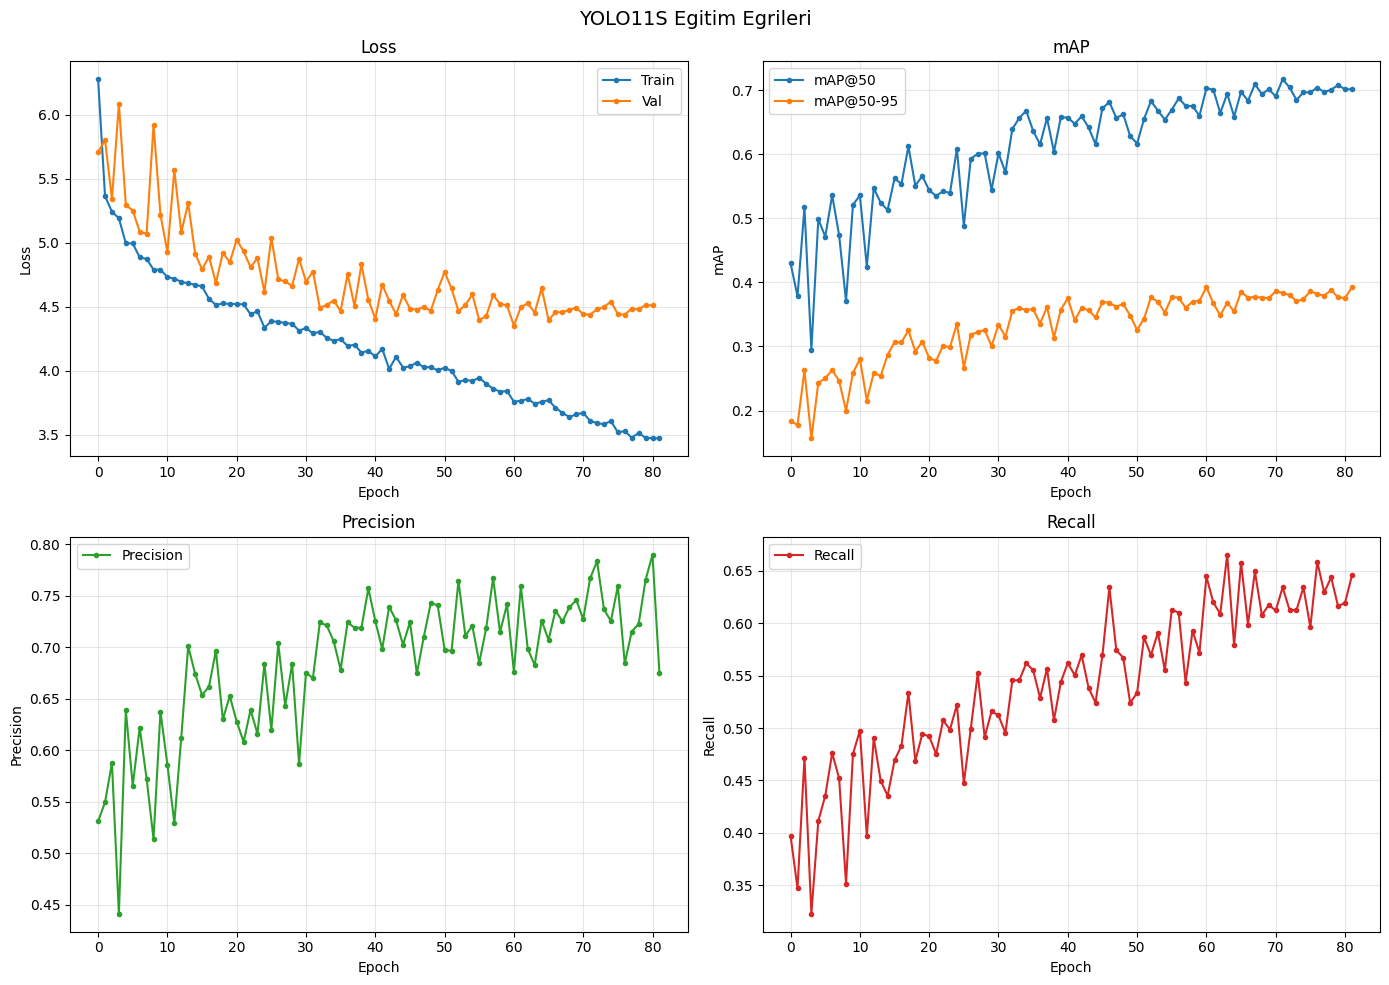

Egitim egrileri kaydedildi: /content/drive/MyDrive/mass_detection/yolo11s/yolo11s_curves.png


In [ ]:
# draw the standard 4 curves from the live Excel log
# canli Excel logundan standart 4 egriyi ciz
curves_path = f'{MODEL_DIR}/{MODEL_NAME}_curves.png'
plot_training_curves(EXCEL_LOG, curves_path, MODEL_NAME.upper())
print('Egitim egrileri kaydedildi:', curves_path)

TP=274  FP=169  FN=126


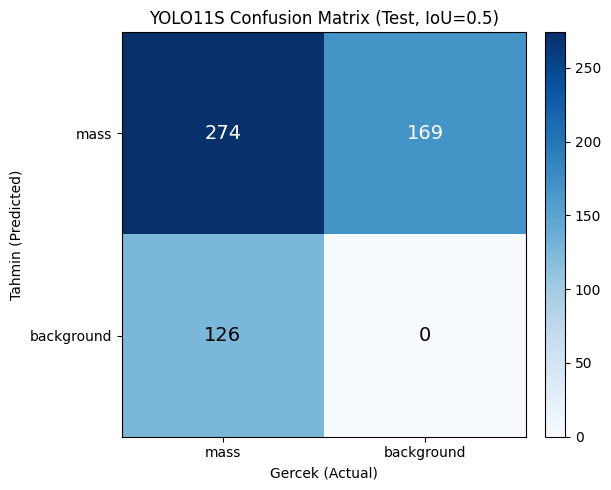

Matristen: Precision=0.619  Recall=0.685
Kaydedildi: /content/drive/MyDrive/mass_detection/yolo11s/yolo11s_confusion_matrix.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# reuse best model and test paths
# en iyi modeli ve test yollarini tekrar kullan
BEST_CKPT = f'{MODEL_DIR}/{MODEL_NAME}_mass/weights/best.pt'
cm_model = YOLO(BEST_CKPT)
TEST_IMG_DIR = Path(DATASET_ROOT) / 'test' / 'images'
TEST_LBL_DIR = Path(DATASET_ROOT) / 'test' / 'labels'


def iou_xywh(b1, b2):
    # IoU of two normalized xywh boxes
    # iki normalize xywh kutunun IoU'su
    def corners(b):
        x, y, w, h = b
        return [x-w/2, y-h/2, x+w/2, y+h/2]
    a, b = corners(b1), corners(b2)
    inter = max(0, min(a[2], b[2])-max(a[0], b[0])) * max(0, min(a[3], b[3])-max(a[1], b[1]))
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/ua if ua > 0 else 0


def load_gt(stem):
    # read ground truth boxes
    # gercek kutulari oku
    lp = TEST_LBL_DIR / f'{stem}.txt'
    gts = []
    if lp.exists():
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                gts.append([float(x) for x in parts[1:5]])
    return gts


# accumulate TP, FP, FN over the whole test set
# tum test seti uzerinde TP, FP, FN topla
TP = FP = FN = 0
IOU_THR = 0.5
CONF_THR = 0.25

all_imgs = sorted(TEST_IMG_DIR.glob('*.png'))
for ip in all_imgs:
    res = cm_model.predict(str(ip), imgsz=1024, conf=CONF_THR, verbose=False)[0]
    preds = []
    if res.boxes is not None and len(res.boxes) > 0:
        preds = [list(b) for b in res.boxes.xywhn.cpu().numpy()]
    gts = load_gt(ip.stem)

    matched = set()
    for pb in preds:
        best, bj = 0, -1
        for j, gb in enumerate(gts):
            if j in matched:
                continue
            i = iou_xywh(pb, gb)
            if i > best:
                best, bj = i, j
        if best >= IOU_THR:
            TP += 1
            matched.add(bj)
        else:
            FP += 1
    FN += len(gts) - len(matched)

print(f'TP={TP}  FP={FP}  FN={FN}')

# 2x2 matrix: rows predicted (mass/background), cols actual (mass/background)
# 2x2 matris: satir tahmin (mass/background), sutun gercek (mass/background)
# background-background is undefined in detection, shown as 0
# detection'da background-background tanimsiz, 0 gosterilir
cm = np.array([[TP, FP],
               [FN, 0]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

labels = ['mass', 'background']
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Gercek (Actual)')
ax.set_ylabel('Tahmin (Predicted)')
ax.set_title(f'{MODEL_NAME.upper()} Confusion Matrix (Test, IoU={IOU_THR})')

# write counts inside cells
# hucre icine sayilari yaz
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        color = 'white' if val > cm.max()/2 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=14)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = f'{MODEL_DIR}/{MODEL_NAME}_confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

# quick sanity: precision and recall from matrix should match test metrics
# hizli kontrol: matristen precision ve recall test metrikleriyle uyusmali
prec = TP/(TP+FP) if (TP+FP) > 0 else 0
rec = TP/(TP+FN) if (TP+FN) > 0 else 0
print(f'Matristen: Precision={prec:.3f}  Recall={rec:.3f}')
print('Kaydedildi:', cm_path)

Secilen ornek: 9
  Dogru: 032ab9e0ecd5fd673517ffa3eb805d15.png
  Dogru: 058e5f91678b4d3dac39bf1b6a798a22.png
  Dogru: 0734a9dc7d6d89e8c91458545afeef9d.png
  Dogru: 0d0826dc6e633a7729ea56fa7390c508.png
  Kacirilan: 00be38a5c0566291168fe381ba0028e6.png
  Kacirilan: 11088_RMLO.png
  Kacirilan: 11134_RMLO.png
  Yanlis Alarm: 0c19be554e27e2fdc2fe05ad954e825c.png
  Yanlis Alarm: 11041_RCC.png


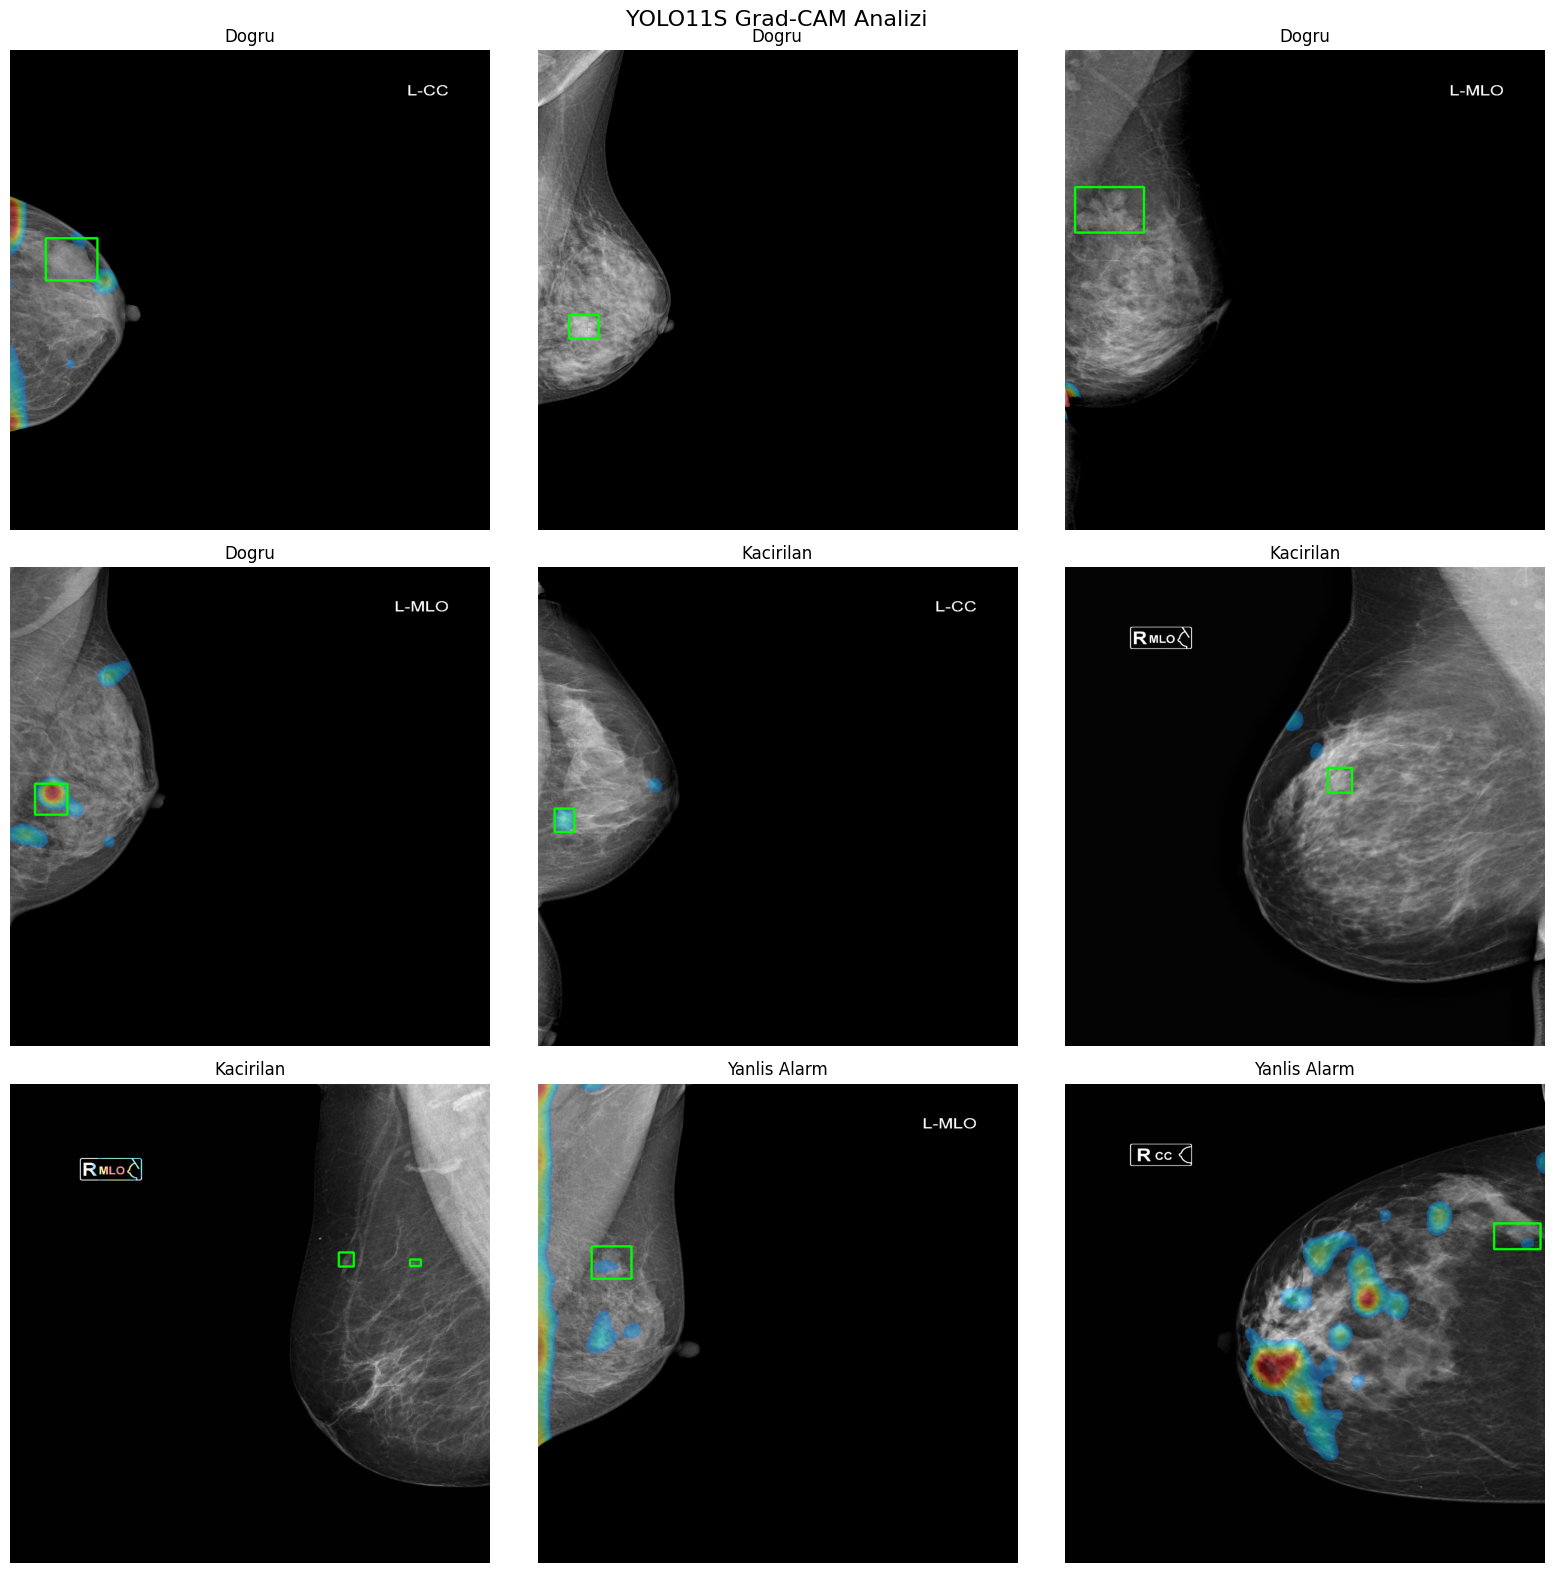

Grad-CAM kaydedildi: /content/drive/MyDrive/mass_detection/yolo11s/yolo11s_gradcam.png


In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# load best model, force to GPU, enable gradients
# en iyi modeli yukle, GPU'ya sabitle, gradyanlari ac
BEST_CKPT = f'{MODEL_DIR}/{MODEL_NAME}_mass/weights/best.pt'
gc_model = YOLO(BEST_CKPT)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tm = gc_model.model.to(device)
tm.eval()
for p in tm.parameters():
    p.requires_grad_(True)

# Grad-CAM settings
# Grad-CAM ayarlari
CAM_THRESH = 0.25  # tissue-masked, logit-based CAM / doku maskeli, logit tabanli CAM
TEST_IMG_DIR = Path(DATASET_ROOT) / 'test' / 'images'
TEST_LBL_DIR = Path(DATASET_ROOT) / 'test' / 'labels'


def iou_xywh(b1, b2):
    def corners(b):
        x, y, w, h = b
        return [x-w/2, y-h/2, x+w/2, y+h/2]
    a, b = corners(b1), corners(b2)
    inter = max(0, min(a[2], b[2])-max(a[0], b[0])) * max(0, min(a[3], b[3])-max(a[1], b[1]))
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/ua if ua > 0 else 0


def load_gt(stem):
    lp = TEST_LBL_DIR / f'{stem}.txt'
    gts = []
    if lp.exists():
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                gts.append([float(x) for x in parts[1:5]])
    return gts


def categorize(img_path):
    # label image as clean / missed / false alarm using IoU matching
    # IoU eslestirme ile goruntuyu temiz / kacirilan / yanlis alarm diye etiketle
    res = gc_model.predict(str(img_path), imgsz=1024, conf=0.25, verbose=False)[0]
    preds = [list(b) for b in res.boxes.xywhn.cpu().numpy()] if (res.boxes is not None and len(res.boxes) > 0) else []
    gts = load_gt(img_path.stem)
    matched = set(); tp = 0
    for pb in preds:
        best, bj = 0, -1
        for j, gb in enumerate(gts):
            if j in matched:
                continue
            i = iou_xywh(pb, gb)
            if i > best:
                best, bj = i, j
        if best >= 0.5:
            tp += 1; matched.add(bj)
    fp = len(preds) - tp
    fn = len(gts) - len(matched)
    if tp > 0 and fp == 0 and fn == 0:
        return 'dogru'
    elif fp > 0 and tp == 0:
        return 'yanlis_alarm'
    elif fn > 0 and tp == 0:
        return 'kacirilan'
    return 'karisik'

def compute_overlay(img_path):
    # Targeted Grad-CAM: backprop from the P3 cell at the detected/true box center
    # Hedefli Grad-CAM: tespit/gercek kutu merkezindeki P3 hucresinden geri yay
    tm.to(device)

    # first get the model's detections for this image
    # once bu goruntu icin modelin tespitlerini al
    res = gc_model.predict(str(img_path), imgsz=1024, conf=0.25, verbose=False)[0]
    det_boxes = res.boxes.xywhn.cpu().numpy() if (res.boxes is not None and len(res.boxes) > 0) else []
    gts = load_gt(img_path.stem)

    # choose target box center: detection if available, else ground truth
    # hedef kutu merkezi sec: varsa tespit, yoksa gercek tumor
    if len(det_boxes) > 0:
        # most confident detection center
        # en guvenli tespitin merkezi
        confs = res.boxes.conf.cpu().numpy()
        bx = det_boxes[confs.argmax()]
        target_cx, target_cy = float(bx[0]), float(bx[1])
    elif len(gts) > 0:
        # missed case: use the true tumor center
        # kacirilan durum: gercek tumor merkezini kullan
        target_cx, target_cy = gts[0][0], gts[0][1]
    else:
        target_cx, target_cy = 0.5, 0.5

    img_bgr = cv2.imread(str(img_path))
    img_r = cv2.resize(img_bgr, (1024, 1024))
    x = torch.from_numpy(img_r[:, :, ::-1].copy()).permute(2, 0, 1).float() / 255.0
    x = x.unsqueeze(0).to(device)
    x.requires_grad_(True)

    # hooks: layer 16 activations + P3 logits
    # hook: layer 16 aktivasyon + P3 logit
    cam_store = {}
    def cam_hook(m, i, o):
        o.retain_grad()
        cam_store['out'] = o
    h_cam = tm.model[16].register_forward_hook(cam_hook)
    logit_store = {}
    def logit_hook(m, i, o):
        logit_store['out'] = o
    h_logit = tm.model[-1].cv3[0].register_forward_hook(logit_hook)

    with torch.enable_grad():
        tm.zero_grad()
        _ = tm(x)
        logits = logit_store['out']            # [1, nc, H, W]
        _, nc, Hh, Ww = logits.shape
        # map target box center to the P3 grid cell
        # hedef kutu merkezini P3 izgara hucresine esle
        gx = min(int(target_cx * Ww), Ww - 1)
        gy = min(int(target_cy * Hh), Hh - 1)
        # backprop from that specific cell's logit
        # o belirli hucrenin logit'inden geri yay
        target = logits[0, :, gy, gx].sum()
        target.backward()

    A = cam_store['out'].detach()
    G = cam_store['out'].grad
    w = G.mean(dim=[2, 3], keepdim=True)
    cam = torch.relu((w * A).sum(dim=1)).squeeze().cpu().numpy()
    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    h_cam.remove()
    h_logit.remove()

    cam_r = cv2.resize(cam.astype('float32'), (1024, 1024))
    cam_r = cv2.GaussianBlur(cam_r, (0, 0), sigmaX=20)
    if cam_r.max() > 0:
        cam_r = cam_r / cam_r.max()

    # tissue mask
    # doku maskesi
    gray = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
    tissue = (gray > 15).astype('float32')
    cam_r = cam_r * tissue

    hm = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET)
    blended = cv2.addWeighted(img_r, 0.6, hm, 0.4, 0)
    mask = (cam_r >= CAM_THRESH)[:, :, None]
    overlay = np.where(mask, blended, img_r).astype(np.uint8)

    # draw ground truth tumor boxes in bright green
    # gercek tumor kutularini parlak yesil ciz
    for (cx, cy, bw, bh) in gts:
        x1 = int((cx - bw/2) * 1024)
        y1 = int((cy - bh/2) * 1024)
        x2 = int((cx + bw/2) * 1024)
        y2 = int((cy + bh/2) * 1024)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 3)

    return overlay

# scan test images, bucket by category
# test goruntulerini tara, kategoriye ayir
all_imgs = sorted(TEST_IMG_DIR.glob('*.png'))
buckets = {'dogru': [], 'kacirilan': [], 'yanlis_alarm': [], 'karisik': []}
for ip in all_imgs[:120]:
    buckets[categorize(ip)].append(ip)

# pick 9: mix of correct and error cases
# 9 sec: dogru ve hatali durum karisimi
selected = []
selected += [(p, 'Dogru') for p in buckets['dogru'][:4]]
selected += [(p, 'Kacirilan') for p in buckets['kacirilan'][:3]]
selected += [(p, 'Yanlis Alarm') for p in buckets['yanlis_alarm'][:2]]
while len(selected) < 9 and buckets['karisik']:
    selected.append((buckets['karisik'].pop(0), 'Karisik'))
selected = selected[:9]

print(f'Secilen ornek: {len(selected)}')
for p, lab in selected:
    print(f'  {lab}: {p.name}')

# 3x3 grid
# 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(16, 16))
for ax, (ip, lab) in zip(axes.flat, selected):
    ov = compute_overlay(ip)
    ax.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
    ax.set_title(lab, fontsize=12)
    ax.axis('off')
for ax in axes.flat[len(selected):]:
    ax.axis('off')

plt.suptitle(f'{MODEL_NAME.upper()} Grad-CAM Analizi', fontsize=16)
plt.tight_layout()
gradcam_path = f'{MODEL_DIR}/{MODEL_NAME}_gradcam.png'
plt.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM kaydedildi:', gradcam_path)